**Magic strikes - Market**

Estimate SPX variance and gamma contracts from bid, ask, and mid implied-volatility smiles. Compare magic-strike approximations through order five with a ten-node Fukasawa benchmark using one of four market snapshots.

In [1]:
# Install from GitHub only when running in Google Colab.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "git+https://github.com/fbourgey/bergomi-guyon.git",
        ],
        check=True,
    )

# Imports

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from magic_strikes.swap import swap_market
from magic_strikes.utils import relative_error

sns.set_theme("talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234
SAVEFIG = False

In [4]:
### Dates used in the paper ###

# date = "20250210"
# date = "20250404"
# date = "20250407"
date = "20250702"


# Use the bundled snapshots locally and fetch them from GitHub in Colab.
if "google.colab" in sys.modules:
    data_path = (
        "https://raw.githubusercontent.com/fbourgey/bergomi-guyon/main/data/"
        f"{date}_spx_vol.csv"
    )
else:
    data_path = f"data/{date}_spx_vol.csv"

ivol_data = pd.read_csv(data_path, index_col=0)
# for now, we remove some outliers in the data for specific dates
# as they have a larger strike than the rest of the data (less strike coverage).

if date in ["20250404"]:
    ivol_data = ivol_data[ivol_data["Texp"] != 9.880e-01].copy()  # remove outlier
if date in ["20250407"]:
    ivol_data = ivol_data[ivol_data["Texp"] != 9.840e-01].copy()  # remove outlier
if date in ["20250702"]:
    ivol_data = ivol_data[
        ~ivol_data["Texp"].isin([7.480e-01, 9.960e-01])
    ].copy()  # remove outlier

expiries = ivol_data["Texp"].unique()

# Variance contract

In [5]:
# variance contract
res = swap_market(
    ivol_data=ivol_data,
    opt="variance",
    n_quad=10,
    extrapolation="flat",
    record_compute_time=True,
)


Expiry 0.0040: variance swap (Fukasawa) using n_quad=10.

Expiry 0.0040: variance swap (magic strikes).

Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)

Expiry 0.0080: variance swap (Fukasawa) using n_quad=10.

Expiry 0.0080: variance swap (magic strikes).

Computing magic strikes for T=0.0080... (1/1)
Computing magic strikes for T=0.0080... (1/1)
Comput

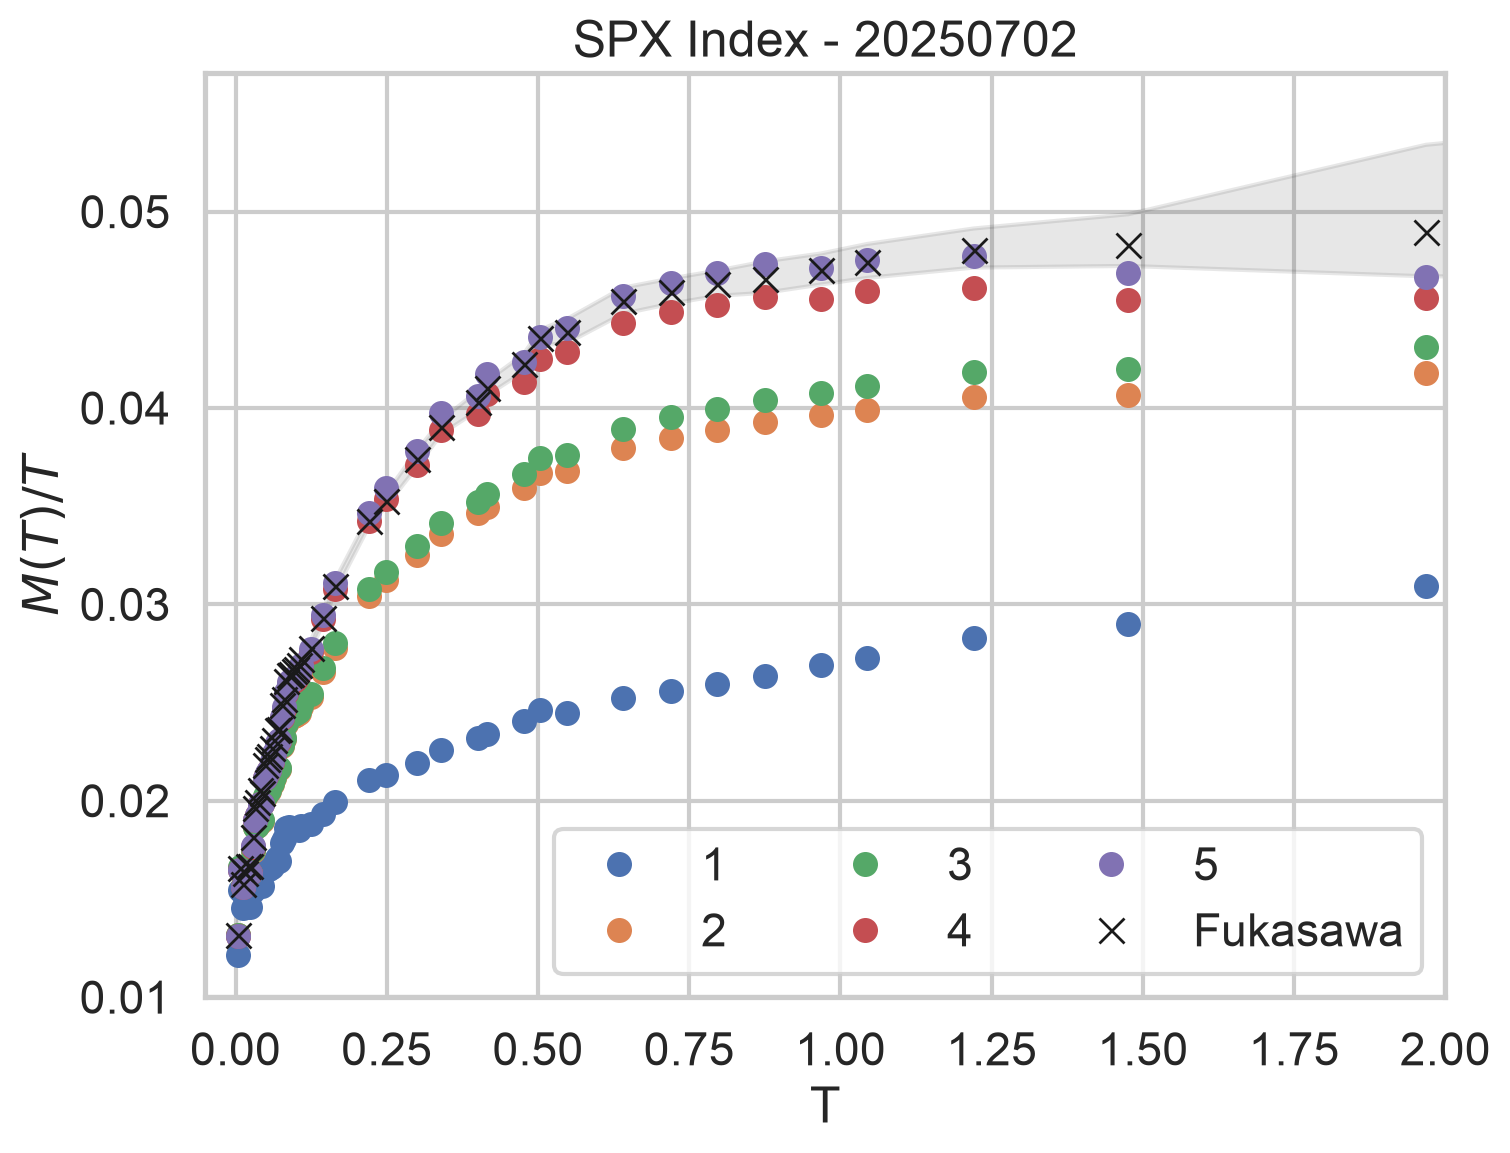

In [6]:
Ts = np.asarray(res["expiries"])
fig, ax = plt.subplots()
# magic strikes
for order in [1, 2, 3, 4, 5]:
    ax.plot(
        Ts,
        res["vs_mid_magic"][order - 1] / Ts,
        ".",
        markersize=16,
        label=f"{order}",
    )
# fukasawa
ax.plot(
    Ts,
    res["vs_mid"] / Ts,
    "kx",
    label="Fukasawa",
)
ax.fill_between(Ts, res["vs_bid"] / Ts, res["vs_ask"] / Ts, color="k", alpha=0.1)
ax.set_xlim(-0.05, 2.0)
ax.legend(ncol=3)
ax.set_xlabel("T")
ax.set_ylabel("$M(T)/T$")
ax.set_title(f"SPX Index - {date}")
if SAVEFIG:
    fig.savefig(f"figures/spx_{date}_vs.pdf", bbox_inches="tight")
plt.show()

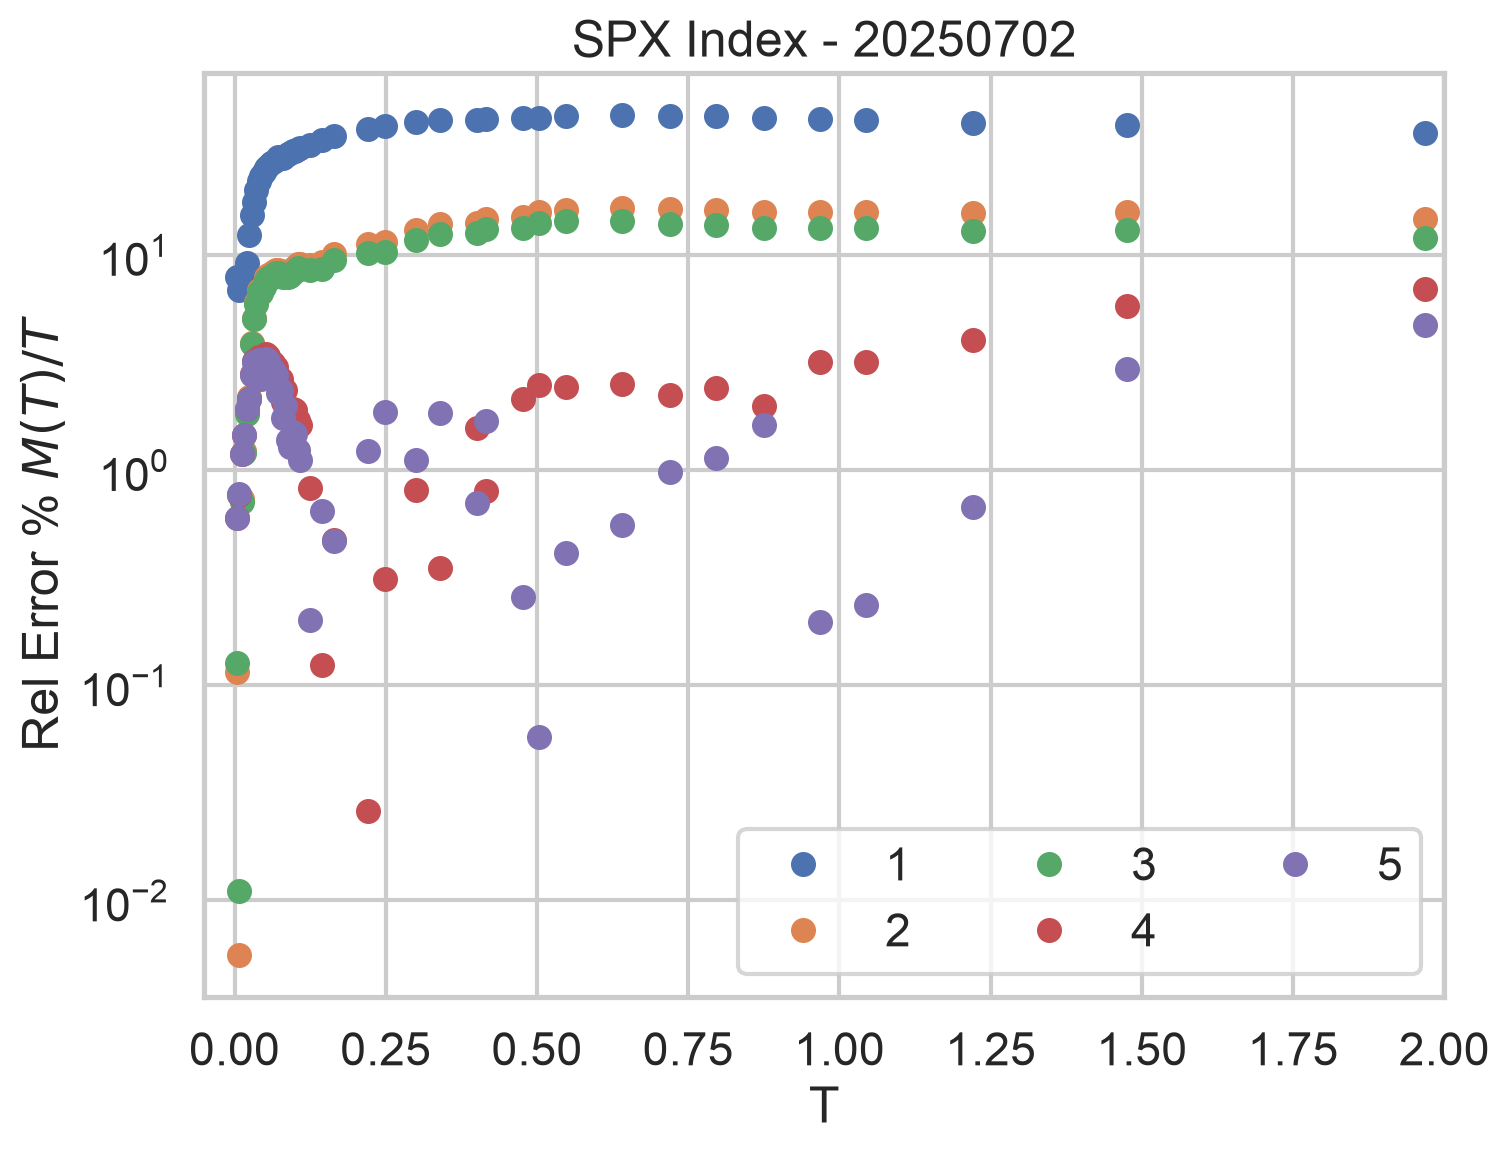

In [7]:
# relative error

Ts = np.asarray(res["expiries"])
ref_values = res["vs_mid"] / Ts

fig, ax = plt.subplots()
# magic strikes
for order in [1, 2, 3, 4, 5]:
    mid_magic_order = res["vs_mid_magic"][order - 1] / Ts
    rel_error = 100 * np.abs(relative_error(ref_values, mid_magic_order))
    ax.semilogy(Ts, rel_error, ".", markersize=16, label=f"{order}")

ax.set_xlim(-0.05, 2.0)
ax.legend(ncol=3)
ax.set_xlabel("T")
ax.set_ylabel("Rel Error % $M(T)/T$")
ax.set_title(f"SPX Index - {date}")
plt.show()

# Gamma contract

In [8]:
res_all = swap_market(
    ivol_data=ivol_data,
    opt="all",
    n_quad=10,
    extrapolation="flat",
)


Expiry 0.0040: variance swap (Fukasawa) using n_quad=10.

Expiry 0.0040: variance swap (magic strikes).

Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)
Computing magic strikes for T=0.0040... (1/1)

Expiry 0.0080: variance swap (Fukasawa) using n_quad=10.

Expiry 0.0080: variance swap (magic strikes).

Computing magic strikes for T=0.0080... (1/1)
Computing magic strikes for T=0.0080... (1/1)
Computing magic strikes for T=0.0080... (1/1)

Expiry 0.0120: variance swap (Fukasawa) using n_quad=10.

Expiry 0.0120: variance swap (magic strikes).

Computing magic strikes for T=0.0120... (1/1)
Computing magic strikes for T=0.0120... (1/1)
Computing magic strikes for T=0.0120... (1/1)

Expiry 0.0160: variance swap (Fukasawa) using n_quad=10.

Expiry 0.0160: variance swap (magic strikes).

Computing magic strikes for T=0.0160... (1/1)
Computing magic strikes for T=0.0160... (1/1)
Computing magic strikes for T=0.0160... (1/1)

Expiry 0.0200: variance

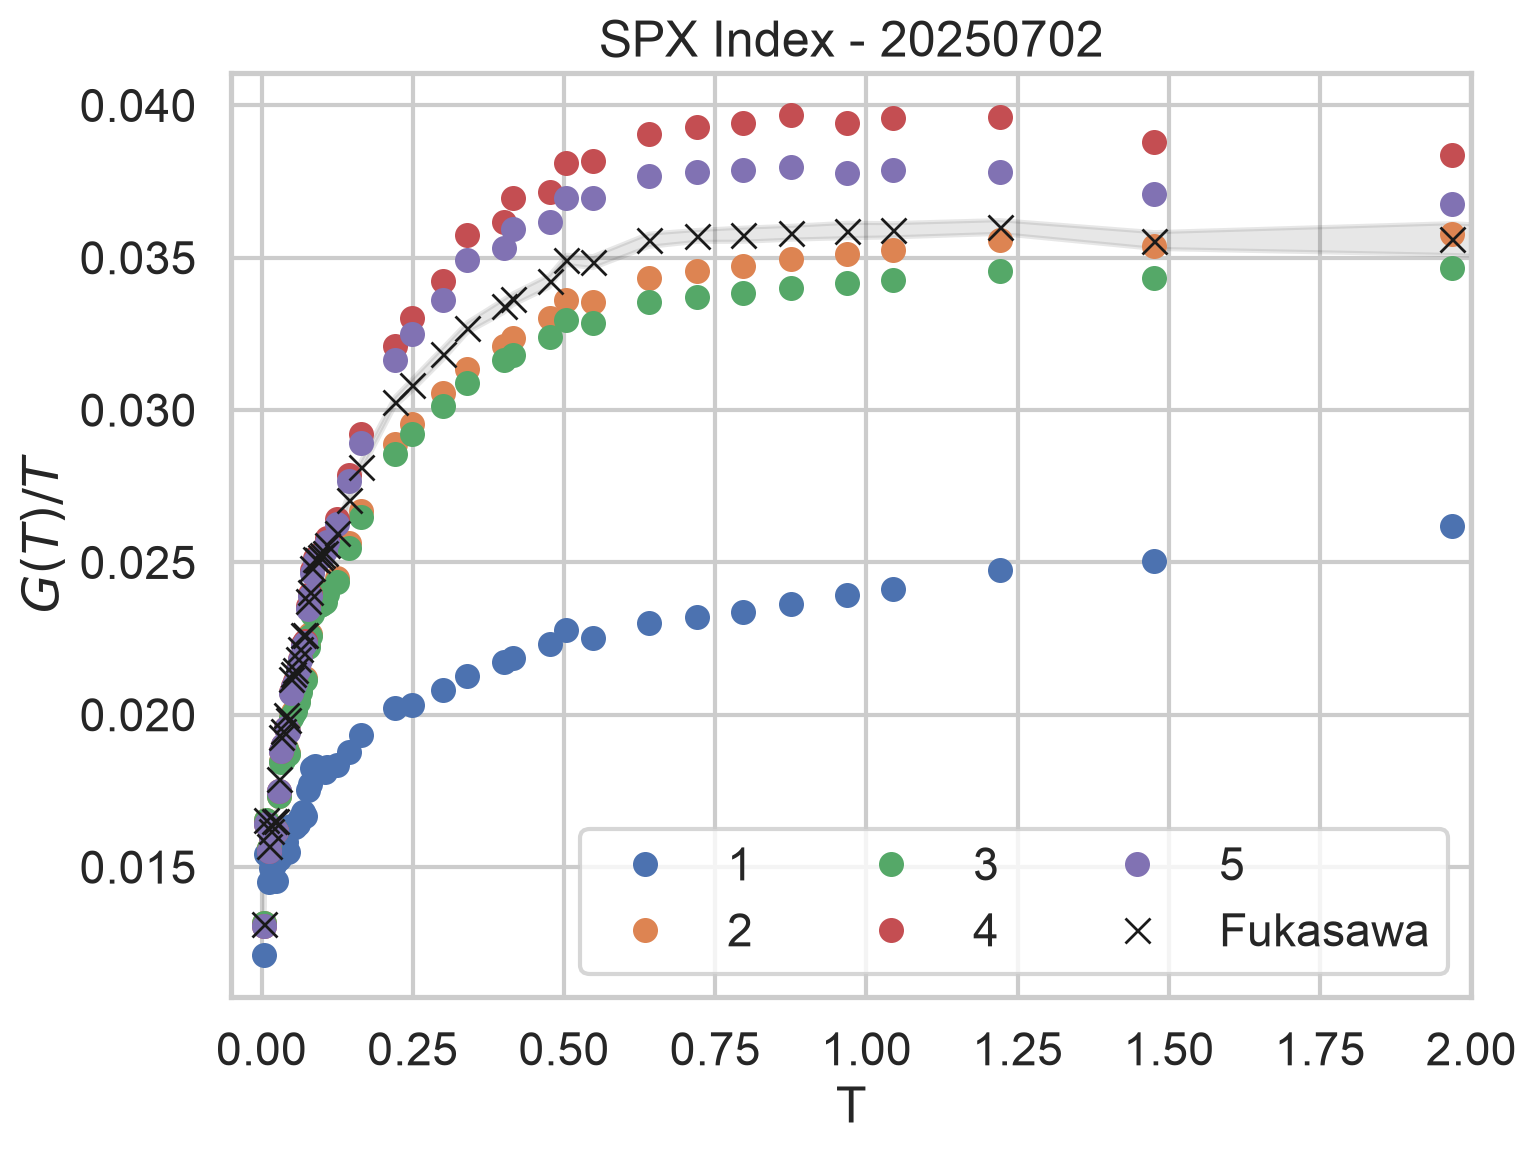

In [9]:
opt = "gamma"
Ts = res_all[opt]["expiries"]
ylabels = {
    "gamma": "$G(T)/T$",
}

fig, ax = plt.subplots()
# magic strikes
for order in [1, 2, 3, 4, 5]:
    ax.plot(
        Ts,
        res_all[opt][f"{opt}_mid_magic"][order - 1] / Ts,
        ".",
        markersize=16,
        label=f"{order}",
    )
# fukasawa
ax.plot(
    Ts,
    res_all[opt][f"{opt}_mid"] / Ts,
    "kx",
    label="Fukasawa",
)
ax.fill_between(
    Ts,
    res_all[opt][f"{opt}_bid"] / Ts,
    res_all[opt][f"{opt}_ask"] / Ts,
    color="k",
    alpha=0.1,
)
ax.set_xlim(-0.05, 2.0)
ax.legend(ncol=3)
ax.set_xlabel("T")
ax.set_ylabel(ylabels[opt])
ax.set_title(f"SPX Index - {date}")
if SAVEFIG:
    fig.savefig(f"figures/spx_{date}_{opt}.pdf", bbox_inches="tight")
plt.show()

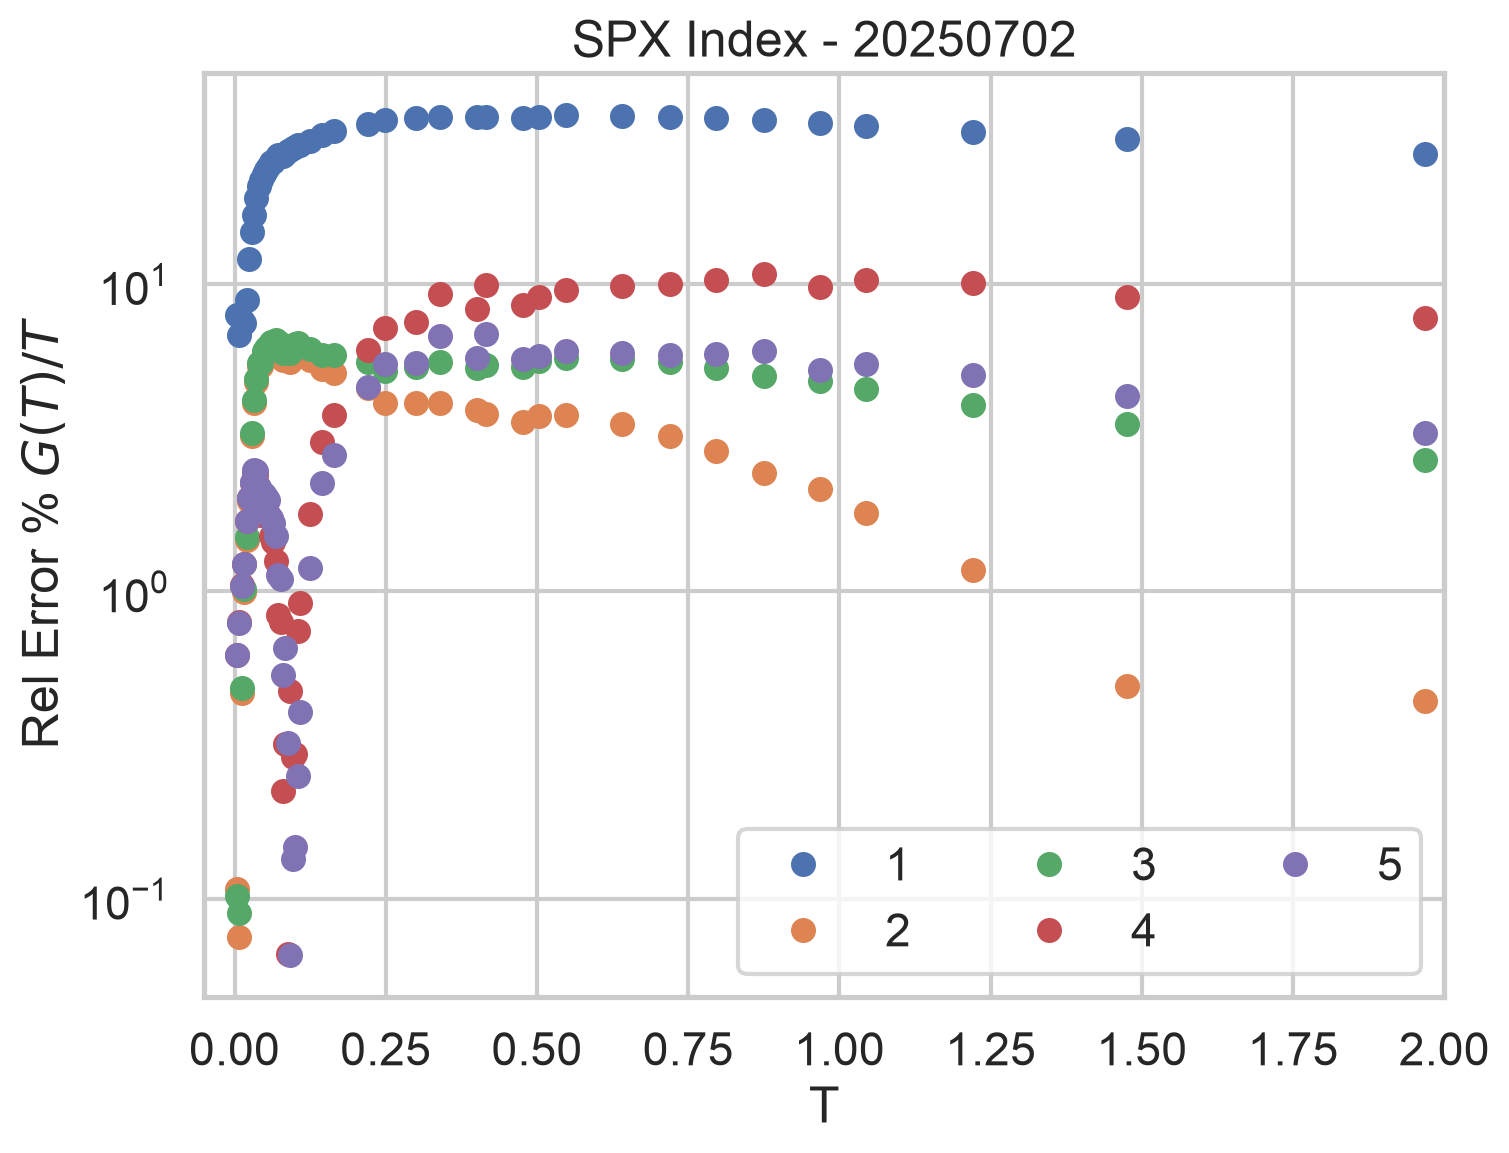

In [10]:
# relative error

opt = "gamma"
Ts = res_all[opt]["expiries"]
ylabels = {"gamma": r"$G(T)/T$"}

ref_values = res_all[opt][f"{opt}_mid"] / Ts

fig, ax = plt.subplots()
# magic strikes
for order in [1, 2, 3, 4, 5]:
    mid_magic_order = res_all[opt][f"{opt}_mid_magic"][order - 1] / Ts
    rel_error = 100 * np.abs(relative_error(ref_values, mid_magic_order))
    ax.semilogy(Ts, rel_error, ".", markersize=16, label=f"{order}")

ax.set_xlim(-0.05, 2.0)
ax.legend(ncol=3)
ax.set_xlabel("T")
ax.set_ylabel(f"Rel Error % {ylabels[opt]}")
ax.set_title(f"SPX Index - {date}")
plt.show()